# TEST: ripulire gli spettri con un autoencoder

### Lettura dati

In [1]:
import numpy as np

# 1. Caricamento dati
f = np.arange(2500, 3250)
s_clean = np.load('../data/test/X_spectra.npy')
B = np.load('../data/test/Y_B_field.npy')

input_shape = s_clean.shape[1]

In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
s_clean_scaled = scaler.fit_transform(s_clean)

### Noising

In [3]:
from ml_odmr.noising import *

# 2. Aggiunta rumore
s_noisy = np.zeros_like(s_clean)
for i in range(s_clean.shape[0]):
    s_noisy[i] = add_poisson_noise(s_clean[i], scale=0.3)
    ''' 
    Per ora sospendo trend e outliers, perché una persona seria li eliminerebbe prima di fare qualsiasi analisi.
    Rimuoverli è semplicissimo, quindi sarebbe come non averli mai aggiunti.
    '''
    #s_noisy[i] = add_poly_trend(f, np.copy(s_clean[i]))
    #s_noisy[i] = add_poisson_noise(s_noisy[i], scale=0.3)
    #s_noisy[i] = add_outliers(s_noisy[i])
    
s_noisy_scaled = scaler.transform(s_noisy)

### Per usare Convolutional NN

In [4]:
# Aggiungiamo la dimensione del canale (da 750 a 750, 1)
s_noisy_scaled = s_noisy_scaled.reshape(-1, input_shape, 1)
s_clean_scaled = s_clean_scaled.reshape(-1, input_shape, 1)

### Modello

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Input
from tensorflow.keras.layers import Conv1D, MaxPooling1D, UpSampling1D, Flatten, Reshape, AveragePooling1D

In [6]:
model = Sequential()
model.add(Input(shape=(input_shape, 1)))

# ================= ENCODER =================
model.add(Conv1D(filters=16, kernel_size=11, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
# Usa AveragePooling invece di MaxPooling per non esaltare i picchi di rumore
model.add(AveragePooling1D(pool_size=2)) 

model.add(Conv1D(filters=32, kernel_size=7, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(AveragePooling1D(pool_size=5)) 

# ================= BOTTLENECK =================
model.add(Flatten()) 

# Aumenta i gradi di libertà fisici. Togli temporaneamente il max_norm per vedere se migliora.
model.add(Dense(32, name='bottleneck')) 
model.add(Activation('relu'))

# ================= DECODER =================
model.add(Dense(75 * 32))
model.add(Activation('relu'))
model.add(Reshape((75, 32))) 

model.add(UpSampling1D(size=5)) 
model.add(Conv1D(filters=16, kernel_size=7, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(UpSampling1D(size=2)) 

# LISCIATURA FINALE: Usa un kernel molto largo per uccidere le oscillazioni
model.add(Conv1D(filters=1, kernel_size=21, padding='same')) 
model.add(Activation('linear'))

In [7]:
# ================= COMPILAZIONE =================
model.compile(optimizer='adam', loss='mean_absolute_error') # mean_squared_error
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 750, 16)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 750, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 750, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 375, 16)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 375, 32)        │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 375, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 375, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 75, 32)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │        76,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2400)           │        79,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 375, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 375, 16)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 375, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 375, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 750, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 750, 1)         │           337 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 750, 1)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,033 (640.75 KB)

 Trainable params: 163,905 (640.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.4595 - val_loss: 0.8625
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1614 - val_loss: 0.8391
Epoch 3/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1089 - val_loss: 0.8181
Epoch 4/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1017 - val_loss: 0.7952
Epoch 5/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0876 - val_loss: 0.7822
Epoch 6/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0786 - val_loss: 0.7698
Epoch 7/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0768 - val_loss: 0.7605
Epoch 8/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0718 - val_loss: 0.7501
Epoch 9/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0680 - val_loss: 0.7404
Epoch 10/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0652 - val_loss: 0.7268
Epoch 11/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0644 - val_loss: 0.7118
Epoch 12/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0

In [ ]:
# FIT (Denoising supervisionato)
history = model.fit(
    s_noisy_scaled, 
    s_clean_scaled, 
    epochs=60,
    batch_size=32,
    validation_split=0.2
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


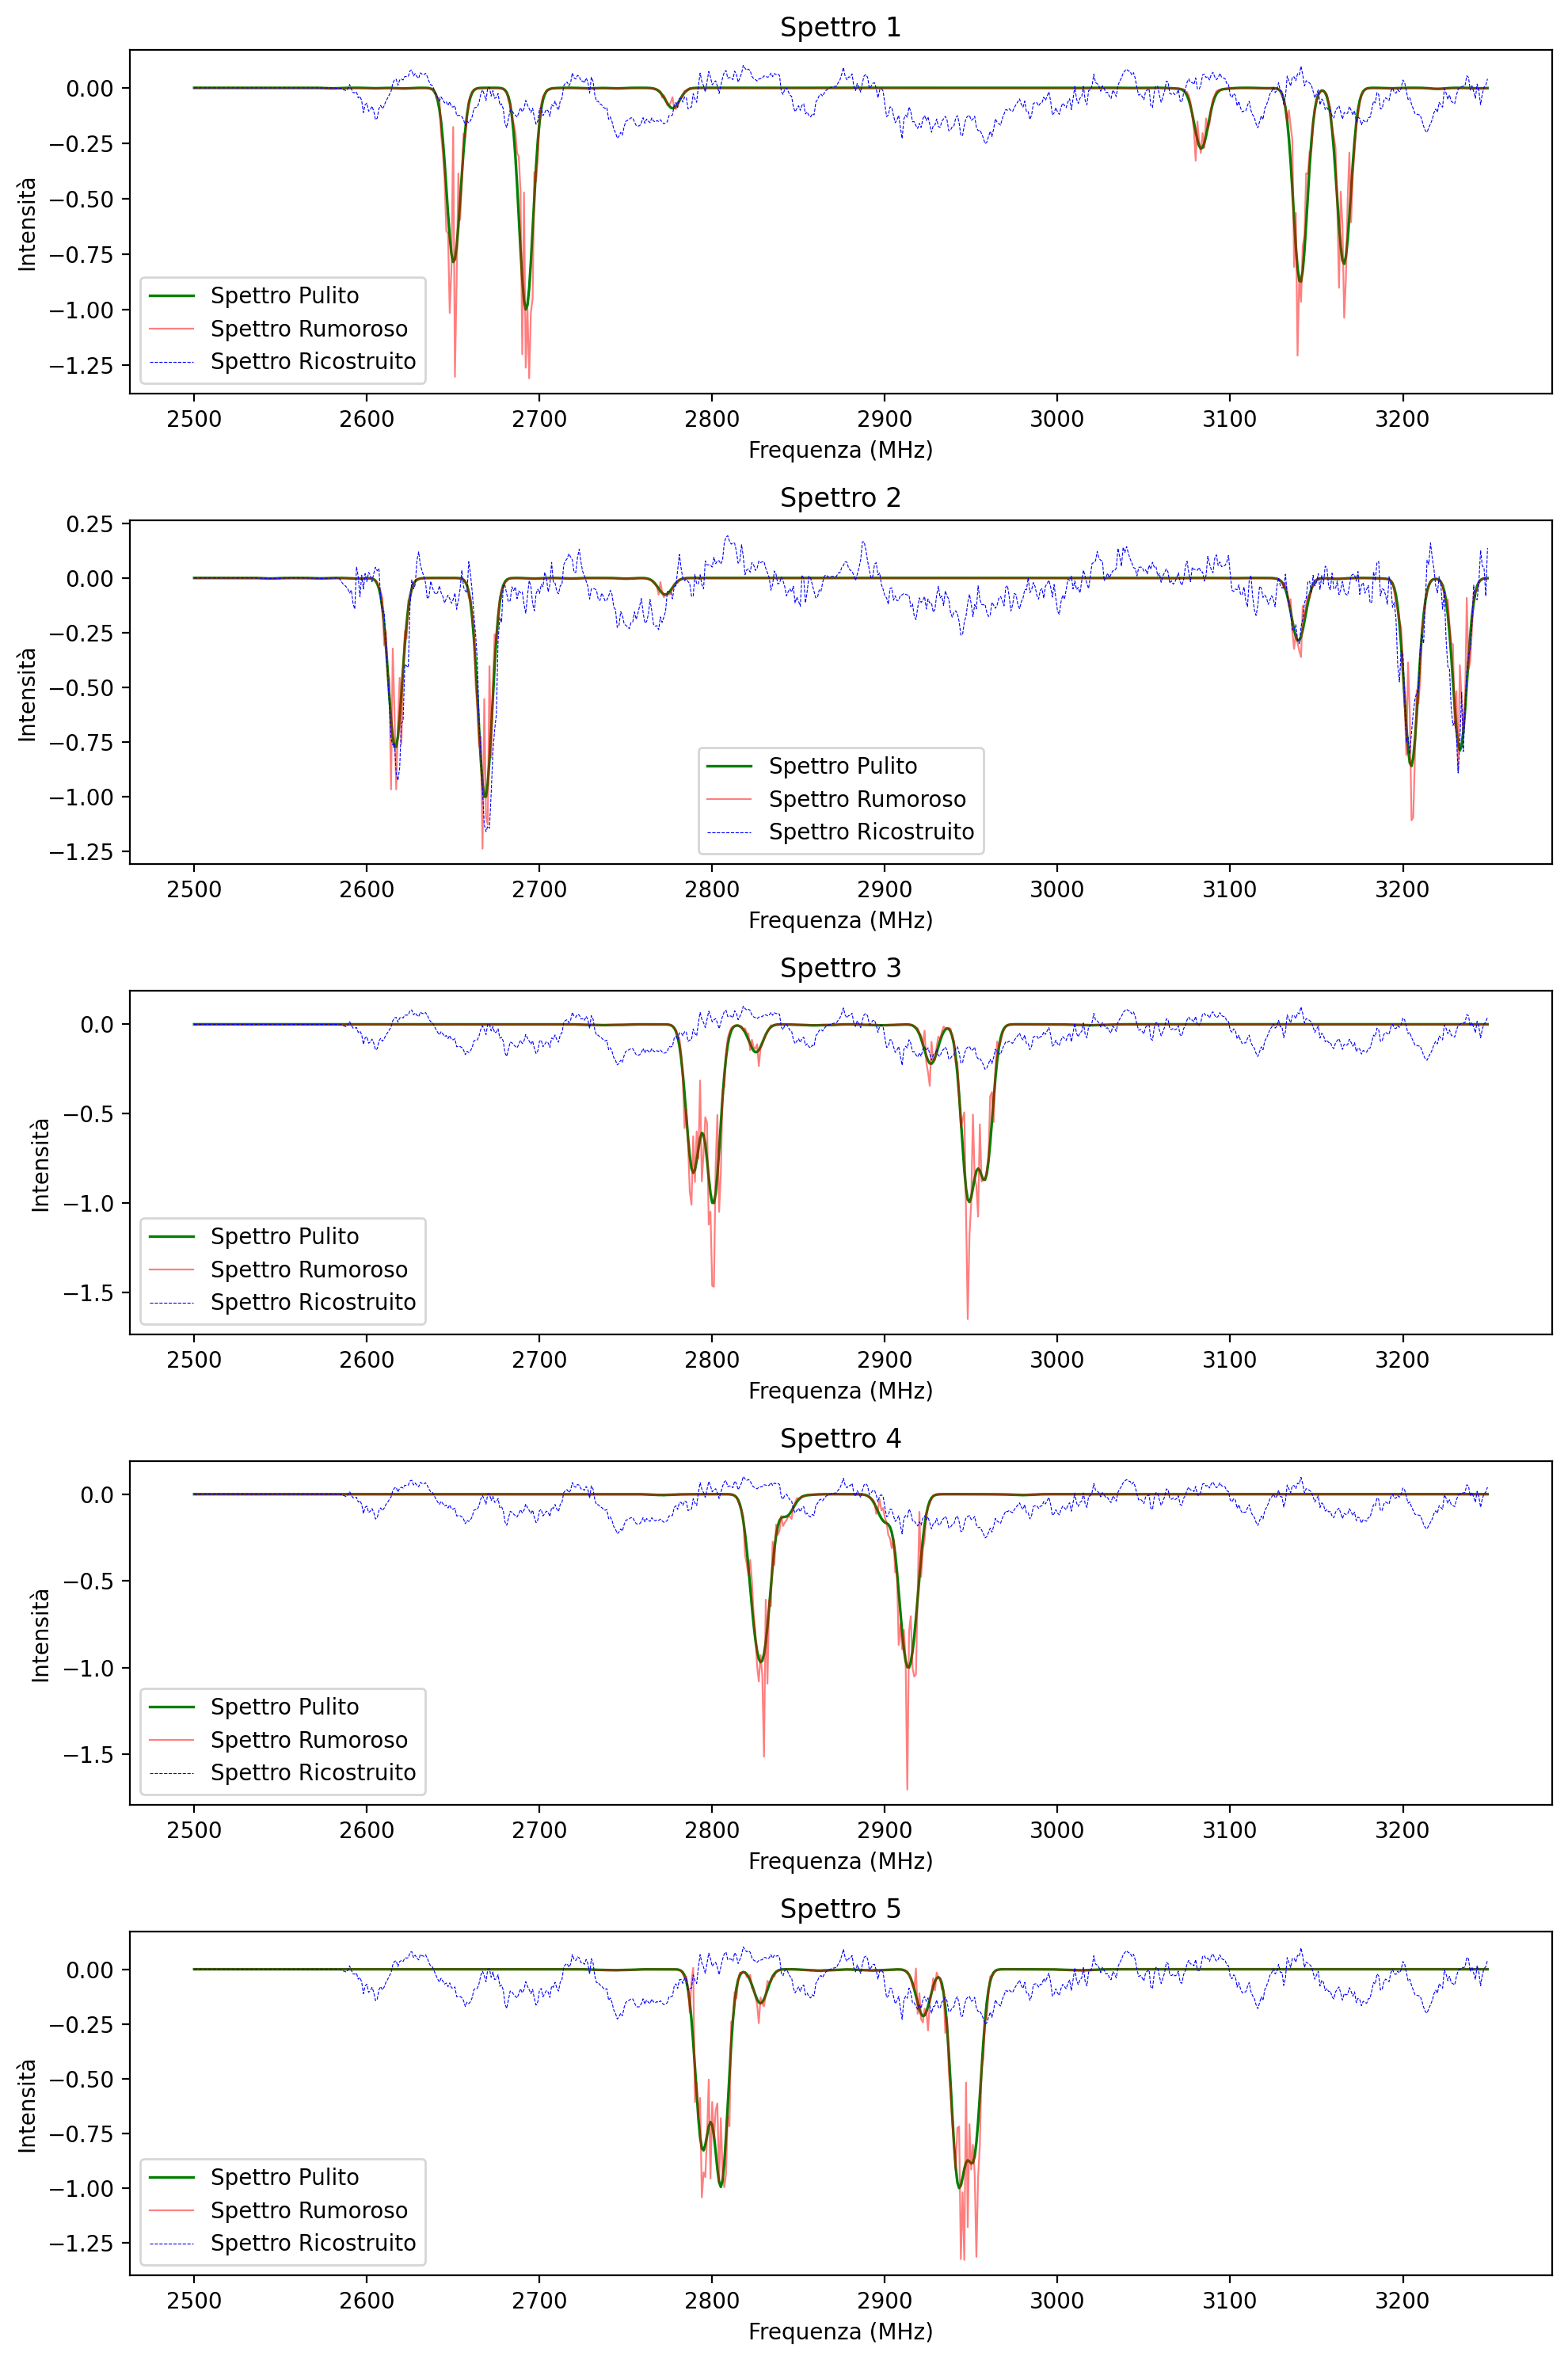

In [8]:
# 5. Ricostruzione (Previsione)
# Simuliamo di voler pulire i primi 5 spettri del nostro dataset
spettri_da_pulire = s_noisy_scaled[:5]
spettri_ricostruiti_scaled = model.predict(spettri_da_pulire)

# Togliamo la dimensione extra del canale usata per la Conv1D
spettri_ricostruiti_scaled = spettri_ricostruiti_scaled.reshape(-1, 750)

# Invertiamo la normalizzazione per riportare i dati alla scala originale
spettri_ricostruiti = scaler.inverse_transform(spettri_ricostruiti_scaled)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 15), dpi=200)
for i in range(5):
    plt.subplot(5, 1, i+1)
    plt.plot(f, s_clean[i], label='Spettro Pulito', color='green', linewidth=1.2)
    plt.plot(f, s_noisy[i], label='Spettro Rumoroso', color='red', alpha=0.5, linewidth=0.8)
    plt.plot(f, spettri_ricostruiti[i], label='Spettro Ricostruito', color='blue', linestyle='dashed', linewidth=0.4)
    plt.legend()
    plt.title(f'Spettro {i+1}')
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
plt.tight_layout()
plt.show()

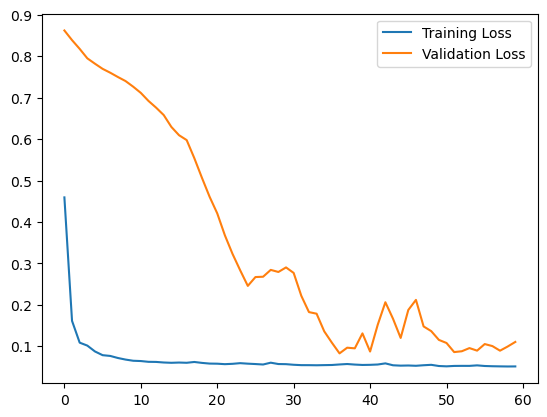

In [9]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()